References:

Research Paper: https://link.springer.com/article/10.1007/s10462-022-10195-4

Naive Bayes: https://www.kaggle.com/code/satarupadeb/na-ve-bayes-classification-spam-email-detection
https://scikit-learn.org/stable/modules/naive_bayes.html

Logistic Regression: https://dev.to/oluwadamisisamuel1/how-to-build-a-logistic-regression-model-a-spam-filter-tutorial-261b

Dataset: https://www.kaggle.com/datasets/ganiyuolalekan/spam-assassin-email-classification-dataset?select=spam_assassin.csv


In [48]:
!pip install imbalanced-learn

# Import packages
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.decomposition import TruncatedSVD
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [49]:
# Load in Data
df = pd.read_csv("spam_assassin.csv")

# Map numeric target to string labels
df["label"] = df["target"].map({0: "ham", 1: "spam"})

X = df["text"].astype(str)
y = df["label"]

print(df["label"].value_counts())


label
ham     3900
spam    1896
Name: count, dtype: int64


Dataset shape: (5796, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5796 entries, 0 to 5795
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5796 non-null   object
 1   target  5796 non-null   int64 
 2   label   5796 non-null   object
dtypes: int64(1), object(2)
memory usage: 136.0+ KB
Class Distribution BEFORE Duplicate Removal:
ham: 3900 (67.29%)
spam: 1896 (32.71%)


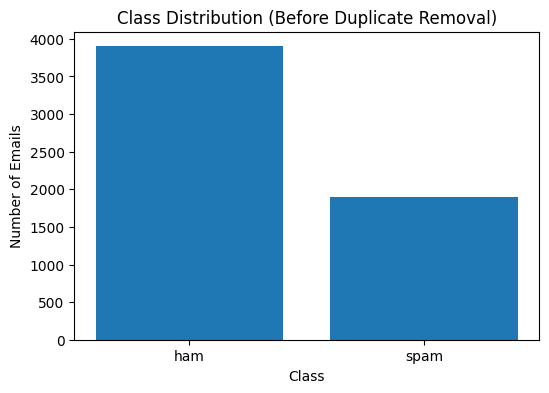

In [50]:
# Pre-processing checks

#1) Basic dataset shape
print("Dataset shape:", df.shape)

#2) Column info
df.info()

# Class distribution BEFORE duplicate removal

original_counts = df["label"].value_counts()
original_percent = df["label"].value_counts(normalize=True) * 100

print("Class Distribution BEFORE Duplicate Removal:")
for label in original_counts.index:
    print(f"{label}: {original_counts[label]} ({original_percent[label]:.2f}%)")

plt.figure(figsize=(6,4))
plt.bar(original_counts.index, original_counts.values)
plt.title("Class Distribution (Before Duplicate Removal)")
plt.ylabel("Number of Emails")
plt.xlabel("Class")
plt.show()

In [51]:
#3) Null value check
print("\nNull values per column:")
print(df.isnull().sum())

#4) Duplicate row check
print("\nNumber of duplicate rows:", df.duplicated().sum())

#5) Empty / whitespace-only text check (for the email text column)
text_col = "text"
empty_count = df[text_col].astype(str).str.strip().eq("").sum()
print("\nNumber of empty/whitespace-only emails:", empty_count)



Null values per column:
text      0
target    0
label     0
dtype: int64

Number of duplicate rows: 467

Number of empty/whitespace-only emails: 0


In [52]:
# Drop duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

# Recreate X and y after cleaning
X = df["text"].astype(str)
y = df["label"]
print("\nUpdated class counts:")
print(df["label"].value_counts())


Rows before: 5796
Rows after: 5329
Duplicates removed: 467

Updated class counts:
label
ham     3638
spam    1691
Name: count, dtype: int64


Class Distribution AFTER Duplicate Removal:
ham: 3638 (68.27%)
spam: 1691 (31.73%)


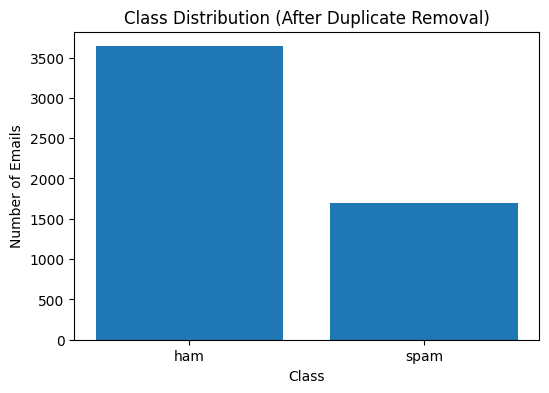

In [53]:

# Class distribution graph implementation
clean_counts = df["label"].value_counts()
clean_percent = df["label"].value_counts(normalize=True) * 100

print("Class Distribution AFTER Duplicate Removal:")
for label in clean_counts.index:
    print(f"{label}: {clean_counts[label]} ({clean_percent[label]:.2f}%)")

plt.figure(figsize=(6,4))
plt.bar(clean_counts.index, clean_counts.values)
plt.title("Class Distribution (After Duplicate Removal)")
plt.ylabel("Number of Emails")
plt.xlabel("Class")
plt.show()


In [54]:
# Train-test split on the data (stratify keeps spam/ham ratio consistent between both sides of the split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=88,
    stratify=y
)

In [55]:
# Shared TF-IDF settings (unigrams only)
tfidf_params = {
    "lowercase": True,
    "stop_words": "english",
    "ngram_range": (1, 1),     # unigrams only
    "min_df": 2,               # ignore very rare words (reduces noise)
    "max_df": 0.95,             # ignore overly common words
    "max_features": 20000
}


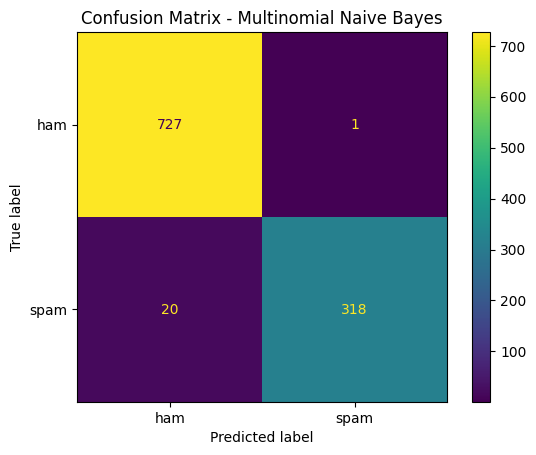


Classification Report - Multinomial Naive Bayes
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       728
        spam       1.00      0.94      0.97       338

    accuracy                           0.98      1066
   macro avg       0.99      0.97      0.98      1066
weighted avg       0.98      0.98      0.98      1066



In [56]:
# Baseline Model: Multinomial Naive Bayes
nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("clf", MultinomialNB())
])

nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, nb_pred)
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.show()

print("\nClassification Report - Multinomial Naive Bayes")
print(classification_report(y_test, nb_pred))


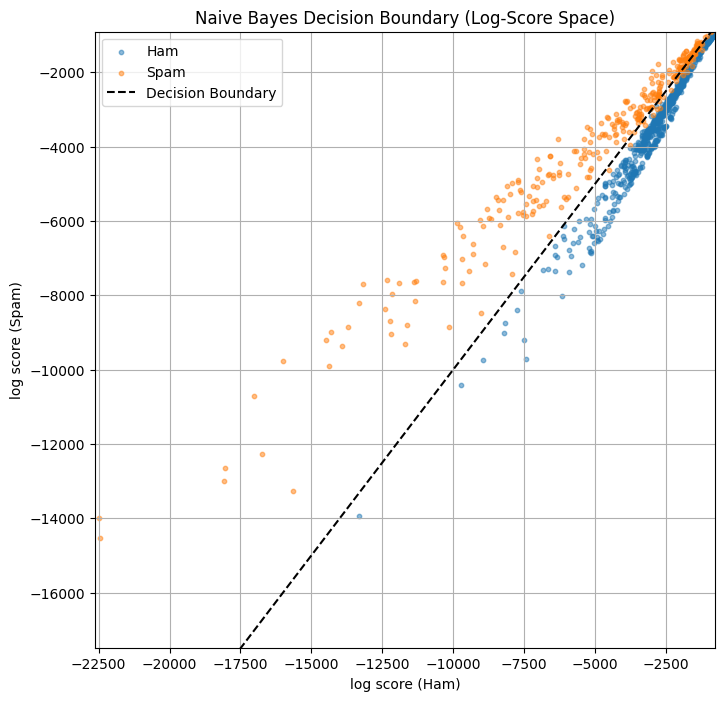

In [57]:
# Fit CountVectorizer on training data to prevent data leakage
cv = CountVectorizer(lowercase=True, stop_words="english", min_df=2)
X_train_counts = cv.fit_transform(X_train)
X_test_counts  = cv.transform(X_test)

# Train NB on TRAIN (visualisation model only)
nb_viz = MultinomialNB(alpha=1.0)
nb_viz.fit(X_train_counts, y_train)

# Use JOINT log likelihood (includes priors) -> looks like the classic plots
jll = nb_viz._joint_log_likelihood(X_test_counts)  # shape: (n_samples, n_classes)
classes = nb_viz.classes_
ham_i  = np.where(classes == "ham")[0][0]
spam_i = np.where(classes == "spam")[0][0]

x = jll[:, ham_i]   # log score for ham
y = jll[:, spam_i]  # log score for spam

# Make the plot readable: clip extreme tails
x_low, x_high = np.percentile(x, [1, 99])
y_low, y_high = np.percentile(y, [1, 99])

plt.figure(figsize=(8,8))
plt.scatter(x[y_test=="ham"],  y[y_test=="ham"],  s=10, alpha=0.5, label="Ham")
plt.scatter(x[y_test=="spam"], y[y_test=="spam"], s=10, alpha=0.5, label="Spam")

# Decision boundary for comparing two class scores: y = x
min_v = min(x_low, y_low)
max_v = max(x_high, y_high)
plt.plot([min_v, max_v], [min_v, max_v], "k--", label="Decision Boundary")

plt.xlim(x_low, x_high)
plt.ylim(y_low, y_high)
plt.xlabel("log score (Ham)")
plt.ylabel("log score (Spam)")
plt.title("Naive Bayes Decision Boundary (Log-Score Space)")
plt.grid(True)
plt.legend()
plt.show()


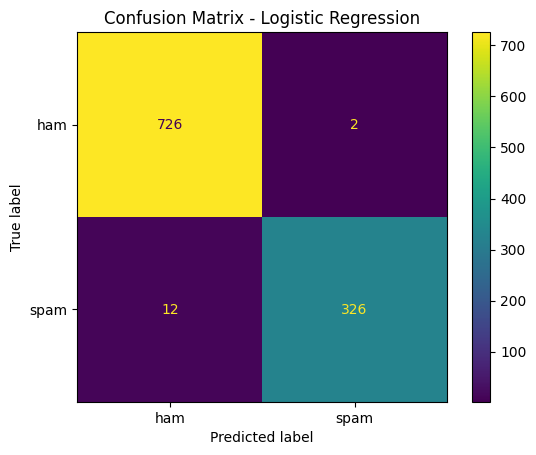


Classification Report - Logistic Regression
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       728
        spam       0.99      0.96      0.98       338

    accuracy                           0.99      1066
   macro avg       0.99      0.98      0.98      1066
weighted avg       0.99      0.99      0.99      1066



In [58]:
# Comparison: Logistic Regression
# Class imbalance exists (more ham than spam)
lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("clf", LogisticRegression(
        max_iter=1000
    ))
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

print("\nClassification Report - Logistic Regression")
print(classification_report(y_test, lr_pred))


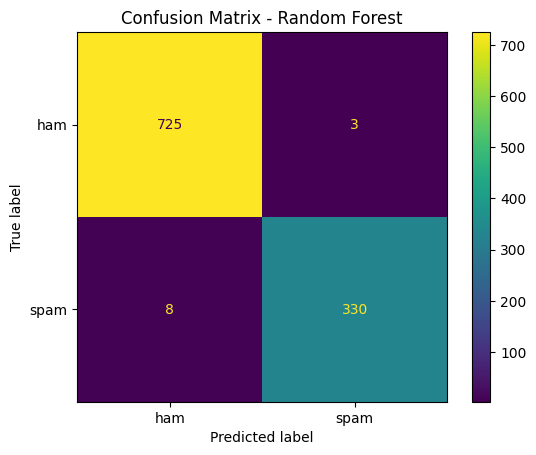


Classification Report - Random Forest
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       728
        spam       0.99      0.98      0.98       338

    accuracy                           0.99      1066
   macro avg       0.99      0.99      0.99      1066
weighted avg       0.99      0.99      0.99      1066



In [59]:
rf_model = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=88,
        n_jobs=-1,
        class_weight="balanced_subsample",
        max_features="sqrt"
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Confusion Matrix - Random Forest")
plt.show()

print("\nClassification Report - Random Forest")
print(classification_report(y_test, rf_pred))

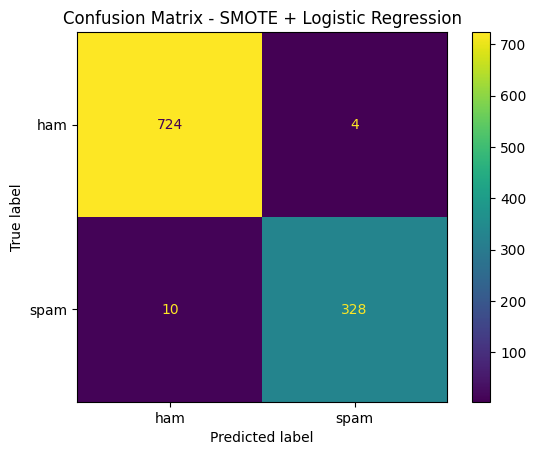


Classification Report - SMOTE + Logistic Regression
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       728
        spam       0.99      0.97      0.98       338

    accuracy                           0.99      1066
   macro avg       0.99      0.98      0.98      1066
weighted avg       0.99      0.99      0.99      1066



In [60]:
# 4th Model: SMOTE + LR
# (TF-IDF -> SVD -> SMOTE -> LR)

svd_components = 300  # typical range: 100-500 for documents like our size 5000+

smote_lr_model = ImbPipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("svd", TruncatedSVD(n_components=svd_components, random_state=88)),
    ("smote", SMOTE(random_state=88)),
    ("clf", LogisticRegression(max_iter=1000))
])

smote_lr_model.fit(X_train, y_train)
smote_pred = smote_lr_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, smote_pred)
plt.title("Confusion Matrix - SMOTE + Logistic Regression")
plt.show()

print("\nClassification Report - SMOTE + Logistic Regression")
print(classification_report(y_test, smote_pred))

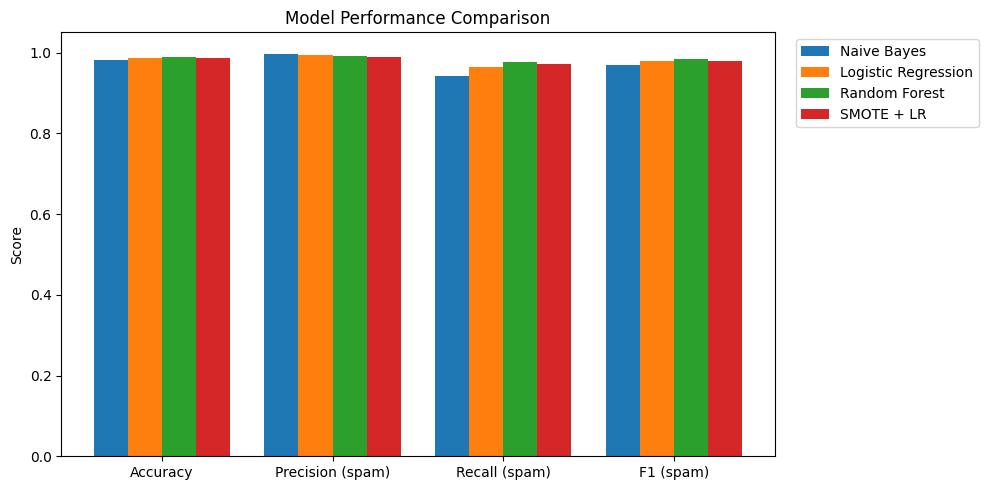

In [61]:
# Model comparison for performance
pos_label = "spam"

nb_scores = [
    accuracy_score(y_test, nb_pred),
    precision_score(y_test, nb_pred, pos_label=pos_label),
    recall_score(y_test, nb_pred, pos_label=pos_label),
    f1_score(y_test, nb_pred, pos_label=pos_label)
]

lr_scores = [
    accuracy_score(y_test, lr_pred),
    precision_score(y_test, lr_pred, pos_label=pos_label),
    recall_score(y_test, lr_pred, pos_label=pos_label),
    f1_score(y_test, lr_pred, pos_label=pos_label)
]

rf_scores = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred, pos_label=pos_label),
    recall_score(y_test, rf_pred, pos_label=pos_label),
    f1_score(y_test, rf_pred, pos_label=pos_label)
]

smote_scores = [
    accuracy_score(y_test, smote_pred),
    precision_score(y_test, smote_pred, pos_label=pos_label),
    recall_score(y_test, smote_pred, pos_label=pos_label),
    f1_score(y_test, smote_pred, pos_label=pos_label)
]

metrics = ["Accuracy", "Precision (spam)", "Recall (spam)", "F1 (spam)"]
x = np.arange(len(metrics))
width = 0.2  # 4 models

plt.figure(figsize=(10,5))

plt.bar(x - 1.5*width, nb_scores, width, label="Naive Bayes")
plt.bar(x - 0.5*width, lr_scores, width, label="Logistic Regression")
plt.bar(x + 0.5*width, rf_scores, width, label="Random Forest")
plt.bar(x + 1.5*width, smote_scores, width, label="SMOTE + LR")

plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()
